# 23F-0031
# Nalain-e-Muhammad

### Module 1 Model Development
- Logistic Regression 
- Feedforward Neural Network 
- Recurrent Neural Network 
- Long Short-Term Memory 



## Import Required Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import roc_curve, auc, brier_score_loss
from sklearn.calibration import calibration_curve

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Embedding, SimpleRNN, LSTM
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping


## Load Dataset

In [2]:
df = pd.read_csv('Phishing_Email.csv')

df = df.dropna()

df['Email Type'] = df['Email Type'].map({
    'Safe Email':0,
    'Phishing Email':1
})

texts = df['Email Text']
labels = df['Email Type']

df.head()


,Unnamed: 0,Email Text,Email Type
0,0,"re : 6 . 1100 , disc : uniformitarianism , re ...",0
1,1,the other side of * galicismos * * galicismo *...,0
2,2,re : equistar deal tickets are you still avail...,0
3,3,\nHello I am your hot lil horny toy.\n I am...,1
4,4,software at incredibly low prices ( 86 % lower...,1


## Train / Validation / Test Split (80/10/10)

In [3]:
X_train, X_temp, y_train, y_temp = train_test_split(
    texts, labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

print("Train:",len(X_train))
print("Validation:",len(X_val))
print("Test:",len(X_test))


Train: 14907
Validation: 1863
Test: 1864


# Module 1 — Part A: Logistic Regression Baseline

In [4]:
vectorizer = TfidfVectorizer(max_features=5000)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf = vectorizer.transform(X_val)
X_test_tfidf = vectorizer.transform(X_test)

start_train = time.time()

lr_model = LogisticRegression(C=1.0, solver='liblinear')
lr_model.fit(X_train_tfidf, y_train)

train_time = time.time() - start_train

start_inf = time.time()
lr_pred = lr_model.predict(X_test_tfidf)
inf_time = time.time() - start_inf

print(classification_report(y_test, lr_pred))
print("Training Time:", train_time)
print("Inference Time:", inf_time)


              precision    recall  f1-score   support

           0       0.97      0.96      0.97      1133
           1       0.95      0.95      0.95       731

    accuracy                           0.96      1864
   macro avg       0.96      0.96      0.96      1864
weighted avg       0.96      0.96      0.96      1864

Training Time: 0.18900823593139648
Inference Time: 0.0009925365447998047


# Module 1 — Part B: Feedforward Neural Network (FNN)

In [5]:
input_dim = X_train_tfidf.shape[1]

fnn_model = Sequential([
    Dense(256, activation='relu', input_shape=(input_dim,)),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

fnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(patience=3, restore_best_weights=True)

history_fnn = fnn_model.fit(
    X_train_tfidf.toarray(),
    y_train,
    validation_data=(X_val_tfidf.toarray(), y_val),
    epochs=10,
    batch_size=64,
    callbacks=[early_stop]
)


C:\Users\PIXLAPS\miniconda3\envs\LLM\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
233/233 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9289 - loss: 0.1553 - val_accuracy: 0.9716 - val_loss: 0.0718
Epoch 2/10
233/233 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9809 - loss: 0.0441 - val_accuracy: 0.9721 - val_loss: 0.0719
Epoch 3/10
233/233 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9867 - loss: 0.0268 - val_accuracy: 0.9721 - val_loss: 0.0796
Epoch 4/10
233/233 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9886 - loss: 0.0219 - val_accuracy: 0.9726 - val_loss: 0.0894


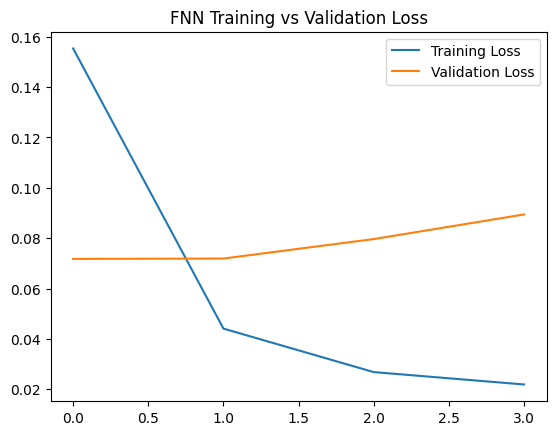

In [6]:
plt.plot(history_fnn.history['loss'], label='Training Loss')
plt.plot(history_fnn.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("FNN Training vs Validation Loss")
plt.show()


# Module 1 — Part C: Vanilla RNN

In [7]:
max_vocab = 10000
max_length = 200

tokenizer = Tokenizer(num_words=max_vocab)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq = tokenizer.texts_to_sequences(X_val)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_length)
X_val_pad = pad_sequences(X_val_seq, maxlen=max_length)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_length)


In [8]:
rnn_model = Sequential([
    Embedding(max_vocab,128,input_length=max_length),
    SimpleRNN(64),
    Dense(1,activation="sigmoid")
])

rnn_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_rnn = rnn_model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad,y_val),
    epochs=5,
    batch_size=64
)


Epoch 1/5


C:\Users\PIXLAPS\miniconda3\envs\LLM\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


233/233 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.8882 - loss: 0.2669 - val_accuracy: 0.9442 - val_loss: 0.1563
Epoch 2/5
233/233 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.9622 - loss: 0.0979 - val_accuracy: 0.9608 - val_loss: 0.1123
Epoch 3/5
233/233 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.9761 - loss: 0.0604 - val_accuracy: 0.9656 - val_loss: 0.0977
Epoch 4/5
233/233 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.9822 - loss: 0.0396 - val_accuracy: 0.9635 - val_loss: 0.1017
Epoch 5/5
233/233 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.9814 - loss: 0.0429 - val_accuracy: 0.9592 - val_loss: 0.1180


# Module 1 — Part D: LSTM

In [9]:
lstm_model = Sequential([
    Embedding(max_vocab,128,input_length=max_length),
    LSTM(64,dropout=0.2,recurrent_dropout=0.2),
    Dense(1,activation="sigmoid")
])

lstm_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_lstm = lstm_model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad,y_val),
    epochs=5,
    batch_size=64
)


Epoch 1/5
233/233 ━━━━━━━━━━━━━━━━━━━━ 26s 102ms/step - accuracy: 0.8990 - loss: 0.2400 - val_accuracy: 0.9603 - val_loss: 0.1062
Epoch 2/5
233/233 ━━━━━━━━━━━━━━━━━━━━ 24s 102ms/step - accuracy: 0.9614 - loss: 0.1004 - val_accuracy: 0.9603 - val_loss: 0.1156
Epoch 3/5
233/233 ━━━━━━━━━━━━━━━━━━━━ 25s 108ms/step - accuracy: 0.9750 - loss: 0.0668 - val_accuracy: 0.9608 - val_loss: 0.1112
Epoch 4/5
233/233 ━━━━━━━━━━━━━━━━━━━━ 25s 106ms/step - accuracy: 0.9799 - loss: 0.0485 - val_accuracy: 0.9619 - val_loss: 0.1187
Epoch 5/5
233/233 ━━━━━━━━━━━━━━━━━━━━ 24s 101ms/step - accuracy: 0.9832 - loss: 0.0420 - val_accuracy: 0.9372 - val_loss: 0.2098


## Generate Predictions for Evaluation

In [11]:
fnn_prob = fnn_model.predict(X_test_tfidf.toarray())
fnn_pred = (fnn_prob > 0.5).astype(int)

rnn_prob = rnn_model.predict(X_test_pad)
rnn_pred = (rnn_prob > 0.5).astype(int)

lstm_prob = lstm_model.predict(X_test_pad)
lstm_pred = (lstm_prob > 0.5).astype(int)

lr_prob = lr_model.predict_proba(X_test_tfidf)[:,1]


59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step


# Module 2 — Part A: Confusion Matrix

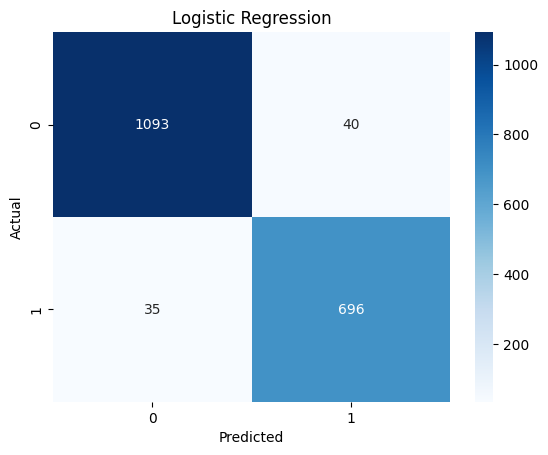

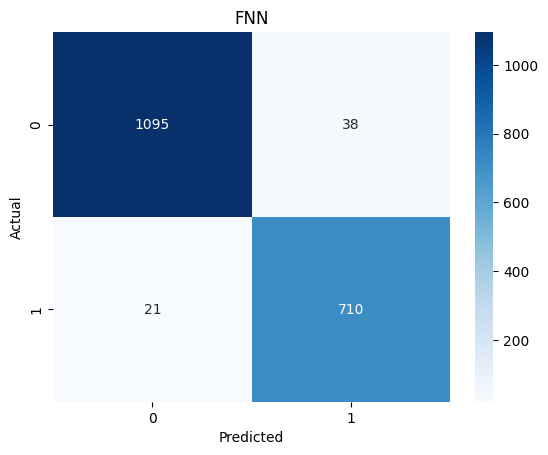

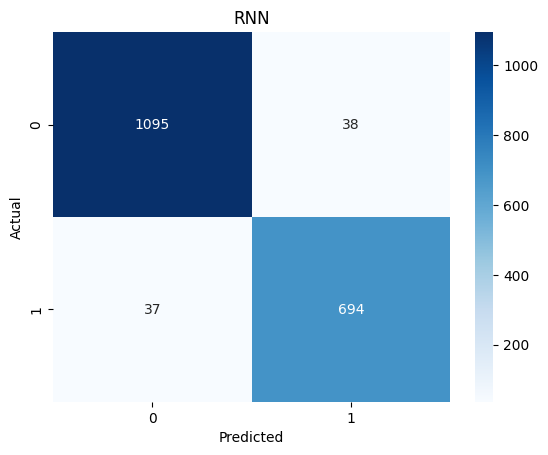

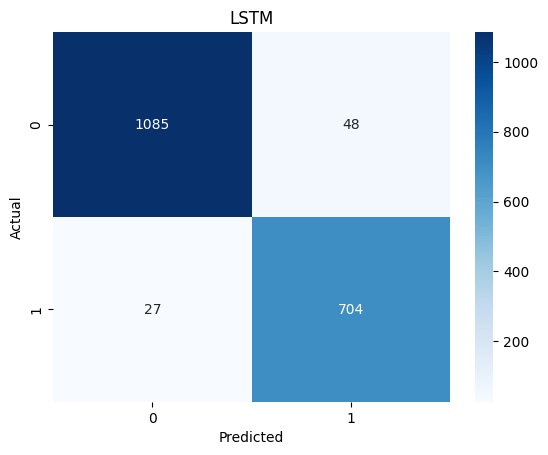

In [12]:
def plot_cm(y_true,y_pred,title):
    cm = confusion_matrix(y_true,y_pred)
    sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

plot_cm(y_test,lr_pred,"Logistic Regression")
plot_cm(y_test,fnn_pred,"FNN")
plot_cm(y_test,rnn_pred,"RNN")
plot_cm(y_test,lstm_pred,"LSTM")


# Module 2 — ROC Curve Comparison

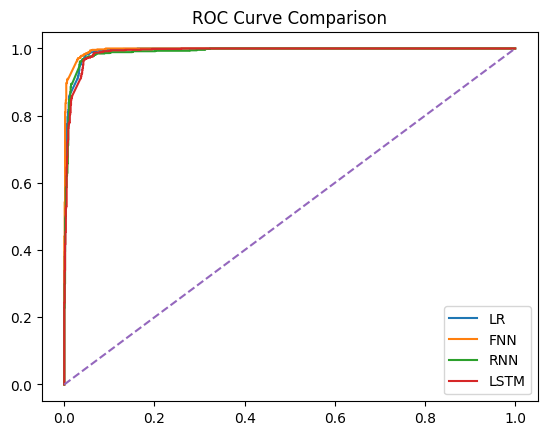

In [13]:
fpr_lr,tpr_lr,_ = roc_curve(y_test,lr_prob)
fpr_fnn,tpr_fnn,_ = roc_curve(y_test,fnn_prob)
fpr_rnn,tpr_rnn,_ = roc_curve(y_test,rnn_prob)
fpr_lstm,tpr_lstm,_ = roc_curve(y_test,lstm_prob)

plt.plot(fpr_lr,tpr_lr,label="LR")
plt.plot(fpr_fnn,tpr_fnn,label="FNN")
plt.plot(fpr_rnn,tpr_rnn,label="RNN")
plt.plot(fpr_lstm,tpr_lstm,label="LSTM")
plt.plot([0,1],[0,1],'--')
plt.legend()
plt.title("ROC Curve Comparison")
plt.show()


# Module 2 — Part B: Summary Metrics Table

In [14]:
summary = pd.DataFrame({
"Model":["Logistic Regression","FNN","RNN","LSTM"],
"Accuracy":[accuracy_score(y_test,lr_pred),
accuracy_score(y_test,fnn_pred),
accuracy_score(y_test,rnn_pred),
accuracy_score(y_test,lstm_pred)],
"Precision":[precision_score(y_test,lr_pred),
precision_score(y_test,fnn_pred),
precision_score(y_test,rnn_pred),
precision_score(y_test,lstm_pred)],
"Recall":[recall_score(y_test,lr_pred),
recall_score(y_test,fnn_pred),
recall_score(y_test,rnn_pred),
recall_score(y_test,lstm_pred)],
"F1":[f1_score(y_test,lr_pred),
f1_score(y_test,fnn_pred),
f1_score(y_test,rnn_pred),
f1_score(y_test,lstm_pred)]
})

summary


,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.959764,0.945652,0.952120,0.948875
1,FNN,0.968348,0.949198,0.971272,0.960108
2,RNN,0.959764,0.948087,0.949384,0.948735
3,LSTM,0.959764,0.936170,0.963064,0.949427


# Module 2 — Part C: Error Analysis

In [18]:
misclassified = np.where(lstm_pred.flatten()!=y_test.values)[0]

for i in misclassified[60:70]:
    print("Email:",X_test.iloc[i])
    print("True Label:",y_test.iloc[i])
    print("Predicted:",lstm_pred[i][0])
    print("-"*80)


Email: clickathome portal is here ! version 2 . 0 of the clickathome portal is now available ! log into www . clickathome . net now , from work or home ! access the pep system through the portal ! choose your reviewers and fill out your evaluations in the comfort and privacy of your home ! outlook web access and ehronline will be available soon ! the clickathome portal is fully customizable for you ! you choose the content on each page , as well as the look and feel ! note : the clickathome portal must be launched through an internet explorer browser , 5 . 0 or higher .
True Label: 0
Predicted: 1
--------------------------------------------------------------------------------
Email: empty
True Label: 0
Predicted: 1
--------------------------------------------------------------------------------
Email: URL: http://diveintomark.org/archives/2002/10/07.html#my_good_easy
Date: 2002-10-07T17:59:05-05:00_Joe Gregorio_: My next pet project[1]. â€œTrying to re-create the "Good 
Easy[2]" on a W